### Benchmark with [CXRO Transmission Grating Efficiency](https://henke.lbl.gov/optical_constants/grating2.html)

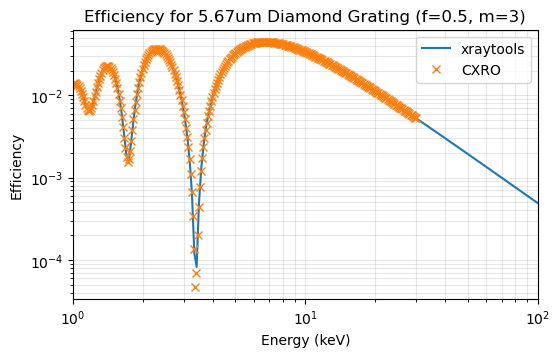

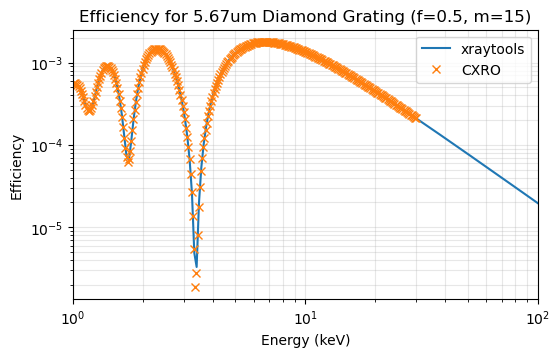

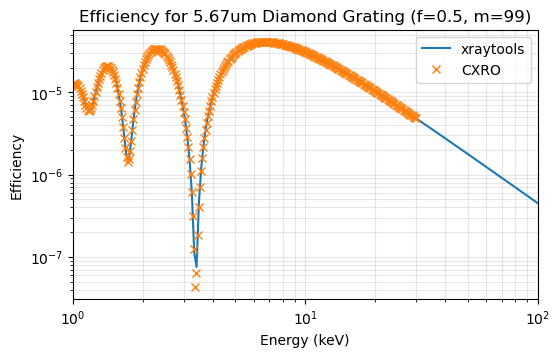

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xraytools as xt

energy_range = np.logspace(np.log10(1), np.log10(100), 200)
thickness = 5.67
pitch = 1.0
f = 0.5  # 50% duty cycle

for order in [3, 15, 99]:
    effs = xt.TransmissionGratingEfficiency(energy_range, order, thickness, f, 'C', density=3.51)
    cxro_effs = np.loadtxt(f'.//grating-efficiency/CXRO-diamond1-order{order}.txt', skiprows=2)

    plt.figure(figsize=(6, 3.5))

    plt.plot(energy_range, effs, label=f'xraytools')
    plt.plot(cxro_effs[:, 0]/1000, cxro_effs[:, 1], 'x', label=f'CXRO')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(1, 100)
    plt.xlabel('Energy (keV)')
    plt.ylabel('Efficiency')
    plt.title(f'Efficiency for {thickness}um Diamond Grating (f={f}, m={order})')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.savefig(f'.//grating-efficiency/diamond1-order{order}.png', dpi=100, bbox_inches='tight')
    plt.show()